In [2]:
# Bibliotecas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D
from tensorflow.keras.models import Model

In [4]:
# Carregar os dados
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
print('x_train.shape: ', x_train.shape)
print('y_train.shape: ', y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2281s 13us/step
x_train.shape:  (50000, 32, 32, 3)
y_train.shape:  (50000,)


In [10]:
K = len(set(y_train)) # Número de classes
print("number of classes:", K)

number of classes: 10


In [11]:
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i) # um filtro reduzir
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x) # aumento de filtros
x = Flatten()(x) # camada de planarização

x = Dropout(0.5)(x) # dropout para evitar overfitting
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x) # função softmax
model = Model(i, x) # criando o modelo

In [12]:
# Compilando e treinando o modelo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 39ms/step - accuracy: 0.4246 - loss: 1.5753 - val_accuracy: 0.5480 - val_loss: 1.2677
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.5422 - loss: 1.2666 - val_accuracy: 0.5863 - val_loss: 1.1389
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.5923 - loss: 1.1335 - val_accuracy: 0.6058 - val_loss: 1.0848
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6297 - loss: 1.0363 - val_accuracy: 0.6529 - val_loss: 0.9836
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 39ms/step - accuracy: 0.6578 - loss: 0.9612 - val_accuracy: 0.6815 - val_loss: 0.9111
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.6820 - loss: 0.8946 - val_accuracy: 0.6951 - val_loss: 0.8720
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 41ms/step - accuracy: 0.6981 - loss: 0.8472 - val_accuracy: 0.6899 - val_loss: 0.8846
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7138 -

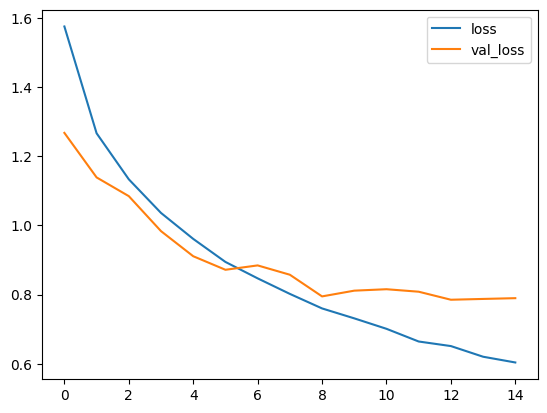

In [13]:
# Grafico de interação do loss
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

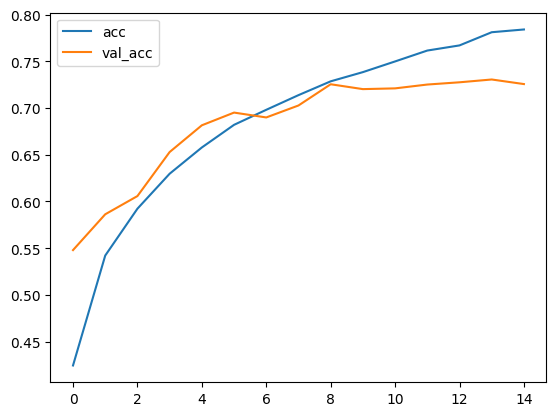

In [14]:
# Grafico de interação da acuracia
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Confusion matrix, without normalization
[[760  13  36  13  32   5  11  20  80  30]
 [ 11 845   6   9   2   5  12   6  28  76]
 [ 59   5 570  52 133  71  64  31  10   5]
 [ 17   8  61 492 112 178  59  44  16  13]
 [ 23   3  36  30 725  38  37 101   4   3]
 [  4   4  45 171  61 616  20  68   4   7]
 [  5   4  35  54  52  28 798  10   9   5]
 [  9   2  21  28  62  40   3 826   4   5]
 [ 49  23   9  11  11   4   5   8 861  19]
 [ 33  94   7  12  11   4   7  22  47 763]]


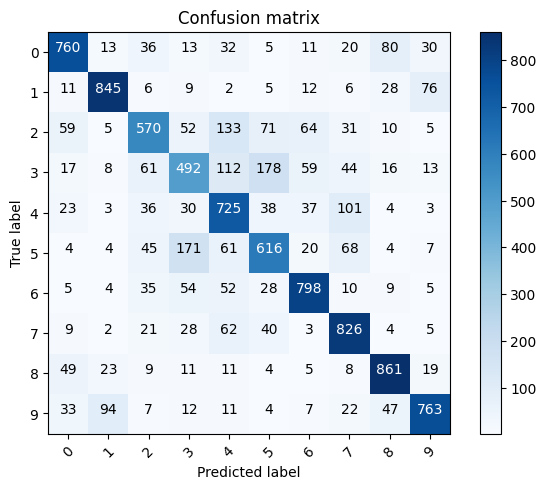

In [15]:
from sklearn.metrics import confusion_matrix # Matriz de confusão
import itertools

def plot_confusion_matrix(cm,
                          classes, # classes
                          normalize=False, # normalização
                          title='Confusion matrix',
                          cmap=plt.cm.Blues # cor
                          ):

    if normalize: # normalização da matriz
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)

    # plotagem da matriz
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # Marcas
    plt.xticks(tick_marks, classes, rotation=45) # rotulos do eixo x
    plt.yticks(tick_marks, classes) # rotulos do eixo y


    fmt = '.2f' if normalize else 'd' # formatação dos números
    thresh = cm.max() / 2. # limiar para a cor do texto
    # colocando texto na matriz
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')

    # rotulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# aplicando a predicao
p_test = model.predict(x_test).argmax(axis=1)
# criando a matriz de confusão
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [16]:
# label mapping
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

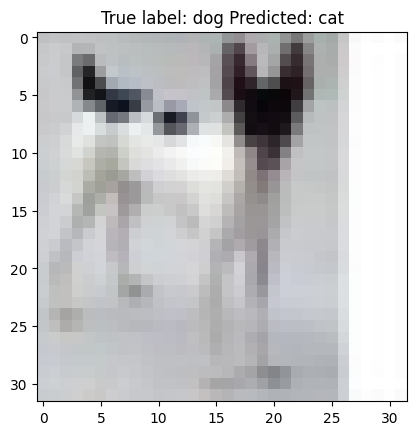

In [17]:
# Adicionando o nome das label
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));